# Практика 3, часть 1
## Изучение продуктивности студентов

#### Вопросы теста:

1. Укажите ваш возраст
2. Выберите ваш курс обучения
3. Сколько часов в сутки вы спите?
4. Как часто вы занимаетесь спортом?
5. Читаете ли вы книги?
6. Хватает ли вам времени на хобби?
7. Сколько часов в сутки в среднем вы проводите в смартфоне?
8. На что вы тратите больше всего времени, когда проводите его в смартфоне? Выберите не более двух вариантов
9. Насколько легко вы справляетесь с учебой?
10. Как часто вы прокрастинируете?
11. Как часто вы чувствуете себя разбитым или уставшим?

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('data.csv')

In [44]:
df.head(5)

,Отметка времени,Укажите ваш возраст,Выберите ваш курс обучения,Сколько часов в сутки вы спите?,Как часто вы занимаетесь спортом?,Читаете ли вы книги?,Хватает ли вам времени на хобби?,Сколько часов в сутки в среднем вы проводите в смартфоне?,"На что вы тратите больше всего времени, когда проводите его в смартфоне? Выберите не более двух вариантов",Насколько легко вы справляетесь с учебой?,Как часто вы прокрастинируете?,Как часто вы чувствуете себя разбитым или уставшим?
0,2026/04/23 1:19:14 PM GMT+5,20,3,7 часов,Раз в неделю,"Да, редко",Да,8 - 10 часов,Скроллинг соцсетей;Игры,2,7,2
1,2026/04/23 1:21:26 PM GMT+5,21,3,8 часов,Раз в неделю,Не читаю,Нет,4 - 6 часов,Коммуникация по учебе или работе;Скроллинг соц...,2,7,5
2,2026/04/23 1:21:45 PM GMT+5,20,3,7 часов,Два - три раза в неделю,"Да, редко",Нет,8 - 10 часов,Коммуникация по учебе или работе;Игры,5,7,7
3,2026/04/23 1:22:01 PM GMT+5,20,3,7 часов,Два - три раза в неделю,Не читаю,Нет,Более 10 часов,Скроллинг соцсетей;Игры,3,5,7
4,2026/04/23 1:26:57 PM GMT+5,20,3,8 часов,Раз в неделю,Не читаю,Да,2 - 4 часа,Коммуникация по учебе или работе;Скроллинг соц...,6,4,5


In [46]:
df = df.drop(['Отметка времени'], axis=1).rename(columns={
    'Укажите ваш возраст': 'age',
    'Выберите ваш курс обучения': 'course',
    'Сколько часов в сутки вы спите?': 'sleep_time',
    'Как часто вы занимаетесь спортом?': 'sport_days',
    'Читаете ли вы книги?': 'reading',
    'Хватает ли вам времени на хобби?': 'hobby',
    'Сколько часов в сутки в среднем вы проводите в смартфоне?': 'sph_time',
    'На что вы тратите больше всего времени, когда проводите его в смартфоне? Выберите не более двух вариантов': 'sph_categories',
    'Насколько легко вы справляетесь с учебой?': 'studying_quality',
    'Как часто вы прокрастинируете?': 'procrastination_level',
    'Как часто вы чувствуете себя разбитым или уставшим?': 'fatigue_level'
})

In [48]:
df.head(3)

,age,course,sleep_time,sport_days,reading,hobby,sph_time,sph_categories,studying_quality,procrastination_level,fatigue_level
0,20,3,7 часов,Раз в неделю,"Да, редко",Да,8 - 10 часов,Скроллинг соцсетей;Игры,2,7,2
1,21,3,8 часов,Раз в неделю,Не читаю,Нет,4 - 6 часов,Коммуникация по учебе или работе;Скроллинг соц...,2,7,5
2,20,3,7 часов,Два - три раза в неделю,"Да, редко",Нет,8 - 10 часов,Коммуникация по учебе или работе;Игры,5,7,7


#### Маппинг ответов

In [51]:
sleep = {
    'Менее 5 часов': 4,
    '5 часов': 5,
    '6 часов': 6,
    '7 часов': 7,
    '8 часов': 8,
    '9 часов': 9,
    '10 часов': 10,
    'Более 10 часов': 11
}

df['sleep_time_mapped'] = df['sleep_time'].map(sleep)

In [53]:
sport = {
    'Не занимаюсь спортом': 0,
    'Раз в неделю': 1,
    'Два - три раза в неделю': 2,
    'Более трех раз в неделю': 3
}

df['sport_days_mapped'] = df['sport_days'].map(sport)

In [55]:
reading = {
    'Да, часто': 2,
    'Да, редко': 1,
    'Не читаю': 0,
}

df['reading_mapped'] = df['reading'].map(reading)

In [57]:
hobby = {
    'Да': 1,
    'Нет': 0,
}

df['hobby_mapped'] = df['hobby'].map(hobby)

In [59]:
sph_time = {
    'Менее 2 часов': 0,
    '2 - 4 часа': 2,
    '4 - 6 часов': 4,
    '6 - 8 часов': 6,
    '8 - 10 часов': 8,
    'Более 10 часов': 10
}

df['sph_time_mapped'] = df['sph_time'].map(sph_time)

In [61]:
dummies = df['sph_categories'].str.get_dummies(sep=';').rename(columns={
    'Коммуникация по учебе или работе': 'ph_communication',
    'Скроллинг соцсетей': 'ph_scrolling',
    'Переписка с друзьями': 'ph_chatting',
    'Просмотр обучающего контента': 'ph_education',
    'Игры': 'ph_games',
    'Другое': 'ph_other'
})

df = pd.concat([df, dummies], axis=1)

In [63]:
df.head(5)

,age,course,sleep_time,sport_days,reading,hobby,sph_time,sph_categories,studying_quality,procrastination_level,...,sport_days_mapped,reading_mapped,hobby_mapped,sph_time_mapped,ph_other,ph_games,ph_communication,ph_chatting,ph_education,ph_scrolling
0,20,3,7 часов,Раз в неделю,"Да, редко",Да,8 - 10 часов,Скроллинг соцсетей;Игры,2,7,...,1,1,1,8,0,1,0,0,0,1
1,21,3,8 часов,Раз в неделю,Не читаю,Нет,4 - 6 часов,Коммуникация по учебе или работе;Скроллинг соц...,2,7,...,1,0,0,4,0,1,1,1,0,1
2,20,3,7 часов,Два - три раза в неделю,"Да, редко",Нет,8 - 10 часов,Коммуникация по учебе или работе;Игры,5,7,...,2,1,0,8,0,1,1,0,0,0
3,20,3,7 часов,Два - три раза в неделю,Не читаю,Нет,Более 10 часов,Скроллинг соцсетей;Игры,3,5,...,2,0,0,10,0,1,0,0,0,1
4,20,3,8 часов,Раз в неделю,Не читаю,Да,2 - 4 часа,Коммуникация по учебе или работе;Скроллинг соц...,6,4,...,1,0,1,2,0,0,1,1,0,1


![Age](age.png)

![Course](course.png)

![Sleep time](sleep.png)

![Sport days](sport.png)

![Reading](reading.png)

![Hobby](hobby.png)

![Smartphone time](ph_time.png)

![Smartphone categories](categories.png)

![Studying quality](studying.png)

![Procrastination level](procrastination.png)

![Fatugue level](fatigue.png)

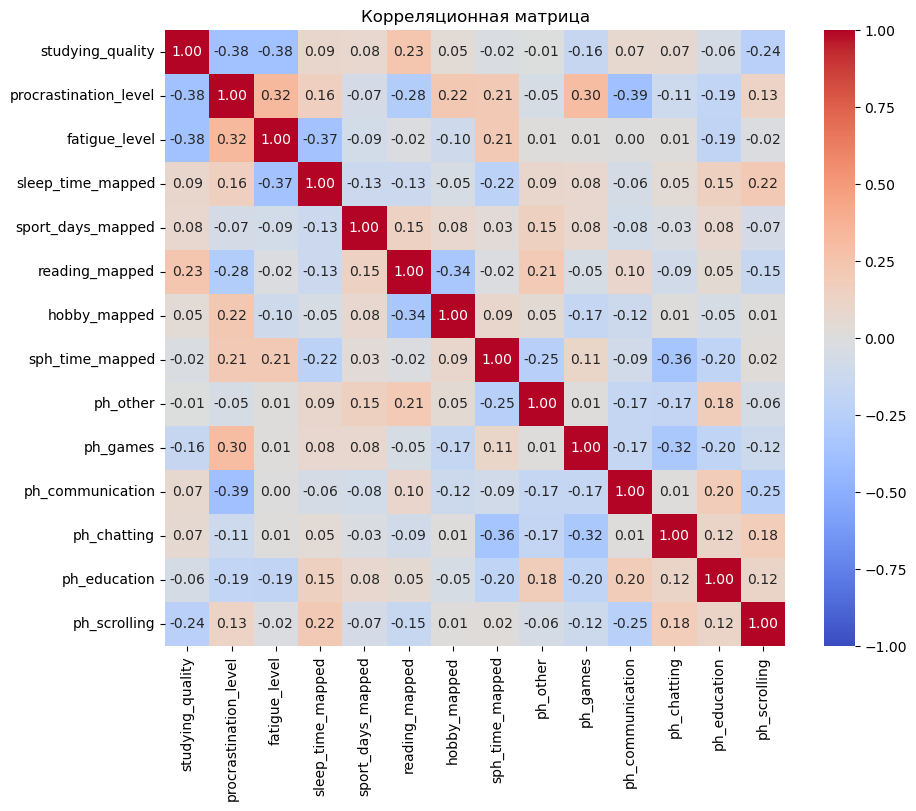

In [76]:
num_cols = df.select_dtypes(include='number').columns
corr_matrix = df[num_cols].drop(['course', 'age'], axis=1).corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

## Закономерности

- Более 80% студентов часто чувствуют себя разбитыми или уставшими
- Более 80% студентов часто прокрастинируют
- Около 70% студентов имеют нормальную длительность сна (7-8 часов)
- Около 40% студентов тратят на смартфон слишком много времени

- Прокрастинирующие студенты чаще чувствуют себя разбитыми и уставшими, и им тяжелее справляться с учебой
- Прокрастинирующие студенты тратят больше времени на смартфон, при этом они чаще играют в игры на смартфоне и реже общаются в мессенджерах по вопросам учебы или работы
- Студентам, которые чаще чувствуют себя уставшими, тяжелее справляться с учебой
- Студенты, которые чаще чувствуют себя более уставшими, меньше спят и тратят больше времени на смартфон
- Читающие студенты легче справляются с учебой
- Игры на смартфоне и переписка с друзьями имеют обратную зависимость. Вероятно, студенты выбирают что-то одно и не выбирают второе


### Необычные закономерности

- Студенты с более высоким уровнем прокрастинации чаще занимаются хобби. Возможное объяснение может заключаться в том, что они тратят время на хобби, из-за чего им не хватает времени на другие важные дела. Другое возможное объяснение - студенты воспринимают время, потраченное на хобби, как время прокрастинации
- Более долгий сон обратно коррелирует с временем потраченным на смартфон. Необычность в том, что сстуденты с более долгим сном чаще проводили время в смартфоне за скроллингом ленты в соцсетях
- У читающих студентов часто не хватает времени на хобби, однако и прокрастинируют они реже
- Студенты, которые тратят больше времени на смартфон, реже тратят много времени на переписку с друзьями. Либо студенты, редко тратящие много времени на переписку с друзьями, тратят больше времени на смартфон

## Выводы

- Прокрастинация негативно влияет на легкость в учебе
- Уровень усталости и уровень прокрастинации взаимосвязаны, однако нельзя однозначно сказать, прокрастинация влияет на усталость или усталость на прокрастинацию
- Чаще прокрастинируют студенты, которые тратя мало времени на общение по учебным или рабочим вопросам и много играют в игры. В то же время читающие студенты меньше подвержены прокрастинации и легче справляются с учебой
- Большое количество времени, потраченное на смартфон, вызывает повышенные усталость и уровень прокрастинации